# Simulated Data Signal Visualization

This notebook generates one synthetic dataset using the same default signal specification pattern as Stage 8 simulation and visualizes signal distributions by type and effect size.

**Fixed parameters**
- `n=400`
- `p=100`
- `class_prevalence=0.2`
- `seed=42`
- default signal specs (`effect_sizes=[0.3, 0.6, 1.0]`, `signals_per_type=3`)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

REPO_ROOT

WindowsPath('C:/Programmering/exjobb/MSc26_Proteomics')

In [2]:
from src.simulation import generate_simulated_dataset

EFFECT_SIZES = [0.3, 0.6, 1.0]
SIGNAL_TYPES = ["linear", "bounded_variance", "u_shape", "threshold"]
SIGNALS_PER_TYPE = 3


def build_default_signal_specs(
    effect_sizes: list[float],
    signals_per_type: int,
) -> list[dict[str, object]]:
    specs: list[dict[str, object]] = []
    for effect in effect_sizes:
        for signal_type in SIGNAL_TYPES:
            specs.append(
                {
                    "signal_type": signal_type,
                    "effect_size": float(effect),
                    "n_features": int(signals_per_type),
                }
            )
        specs.append(
            {
                "signal_type": "xor_pair",
                "effect_size": float(effect),
                "n_pairs": int(signals_per_type),
            }
        )
    return specs


signal_specs = build_default_signal_specs(
    effect_sizes=EFFECT_SIZES,
    signals_per_type=SIGNALS_PER_TYPE,
)

print(f"Built {len(signal_specs)} signal specs.")
signal_specs[:5]

Built 15 signal specs.


[{'signal_type': 'linear', 'effect_size': 0.3, 'n_features': 3},
 {'signal_type': 'bounded_variance', 'effect_size': 0.3, 'n_features': 3},
 {'signal_type': 'u_shape', 'effect_size': 0.3, 'n_features': 3},
 {'signal_type': 'threshold', 'effect_size': 0.3, 'n_features': 3},
 {'signal_type': 'xor_pair', 'effect_size': 0.3, 'n_pairs': 3}]

In [3]:
N = 400
P = 100
CLASS_PREVALENCE = 0.2
SEED = 42

X, y, ground_truth = generate_simulated_dataset(
    n=N,
    p=P,
    class_prevalence=CLASS_PREVALENCE,
    signal_specs=signal_specs,
    seed=SEED,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class counts (0, 1): {np.bincount(y)}")
print("Ground-truth keys:")
print(sorted(ground_truth.keys()))

X shape: (400, 100)
y shape: (400,)
Class counts (0, 1): [320  80]
Ground-truth keys:
['all_signal_indices', 'bounded_variance', 'by_type_effect', 'linear', 'noise_indices', 'signal_records', 'threshold', 'u_shape', 'xor_pair']


In [4]:
effect_sizes = sorted(float(e) for e in EFFECT_SIZES)
all_signal_types = SIGNAL_TYPES + ["xor_pair"]

by_type_effect_raw = ground_truth.get("by_type_effect", {})
by_type_effect: dict[str, dict[float, list[int]]] = {}

for signal_type in all_signal_types:
    effect_map = by_type_effect_raw.get(signal_type, {})
    by_type_effect[signal_type] = {
        float(effect): [int(i) for i in indices]
        for effect, indices in effect_map.items()
    }

xor_records_by_effect: dict[float, list[tuple[int, int]]] = {effect: [] for effect in effect_sizes}
for record in ground_truth.get("signal_records", []):
    if str(record.get("signal_type")) != "xor_pair":
        continue
    effect = float(record.get("effect_size"))
    pair = tuple(int(i) for i in record.get("indices", []))
    if effect in xor_records_by_effect and len(pair) == 2:
        xor_records_by_effect[effect].append(pair)

summary_counts = {
    signal_type: {
        effect: len(by_type_effect[signal_type].get(effect, []))
        for effect in effect_sizes
    }
    for signal_type in all_signal_types
}
summary_counts

{'linear': {0.3: 3, 0.6: 3, 1.0: 3},
 'bounded_variance': {0.3: 3, 0.6: 3, 1.0: 3},
 'u_shape': {0.3: 3, 0.6: 3, 1.0: 3},
 'threshold': {0.3: 3, 0.6: 3, 1.0: 3},
 'xor_pair': {0.3: 6, 0.6: 6, 1.0: 6}}

In [5]:
def plot_signal_histograms(signal_type: str, effects: list[float]) -> None:
    fig, axes = plt.subplots(
        1,
        len(effects),
        figsize=(5 * len(effects), 4),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, effect in zip(axes, effects):
        indices = by_type_effect.get(signal_type, {}).get(effect, [])

        if not indices:
            ax.set_title(f"effect={effect} (no features)")
            ax.set_xlabel("Feature value")
            continue

        representative_idx = int(indices[0])
        x0 = X[y == 0, representative_idx]
        x1 = X[y == 1, representative_idx]

        combined = np.concatenate([x0, x1])
        bins = np.histogram_bin_edges(combined, bins=30)

        ax.hist(x0, bins=bins, alpha=0.55, density=True, label="y=0", color="#0A387D")
        ax.hist(x1, bins=bins, alpha=0.55, density=True, label="y=1", color="#C29717")
        ax.set_title(f"Effect={effect}")
        ax.set_xlabel("Feature value")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Density")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")

    fig.suptitle(f"{signal_type.replace('_', ' ').title()} Signals", y=0.95, fontsize=14)
    fig.tight_layout()
    plt.show()

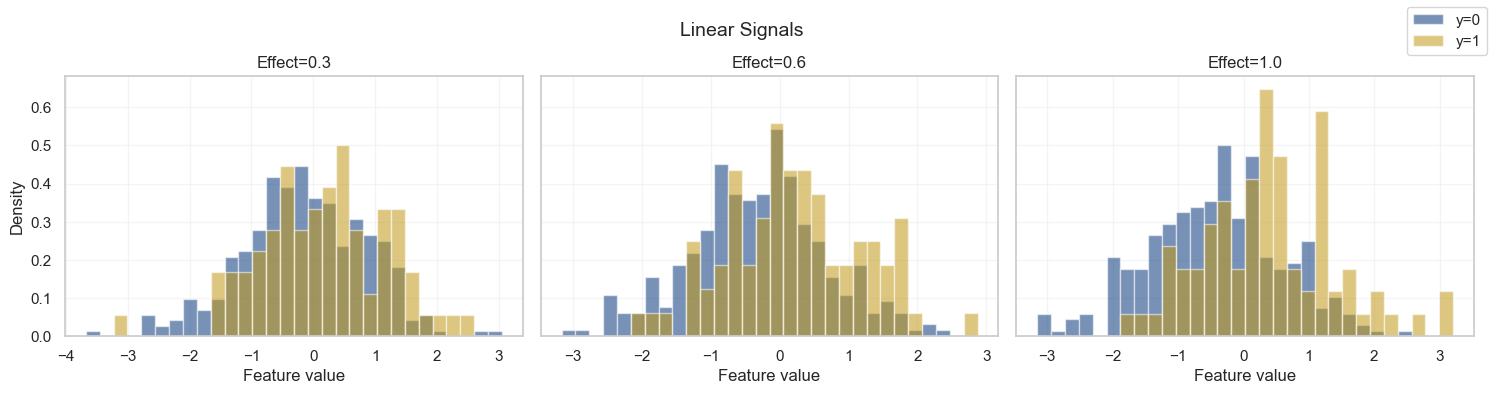

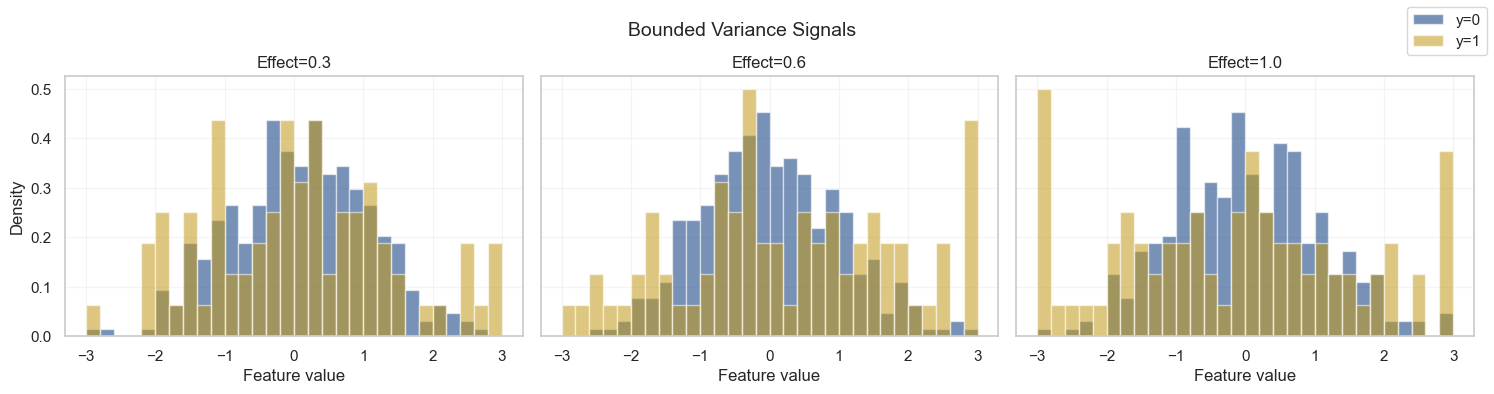

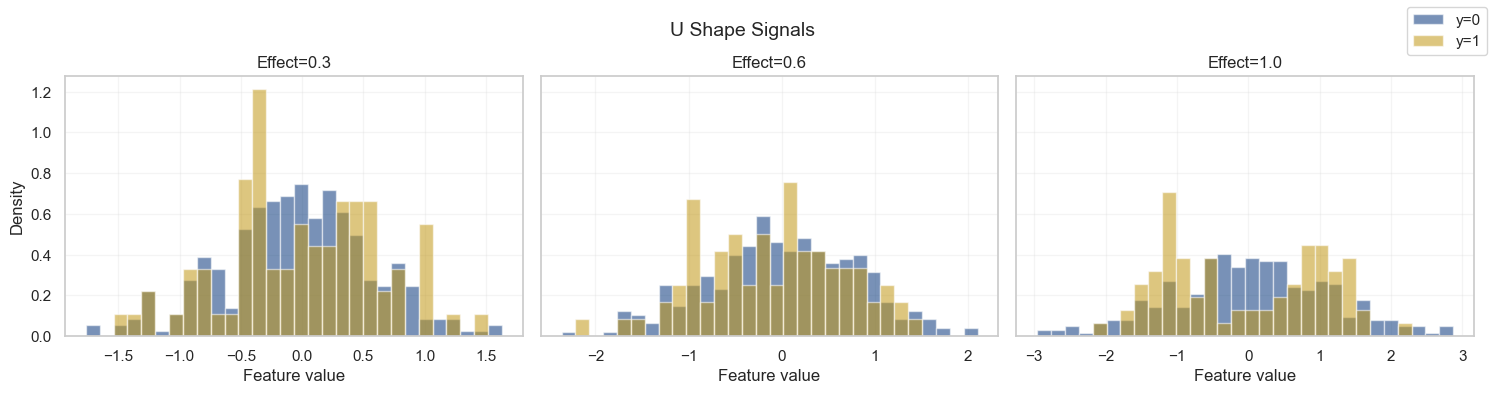

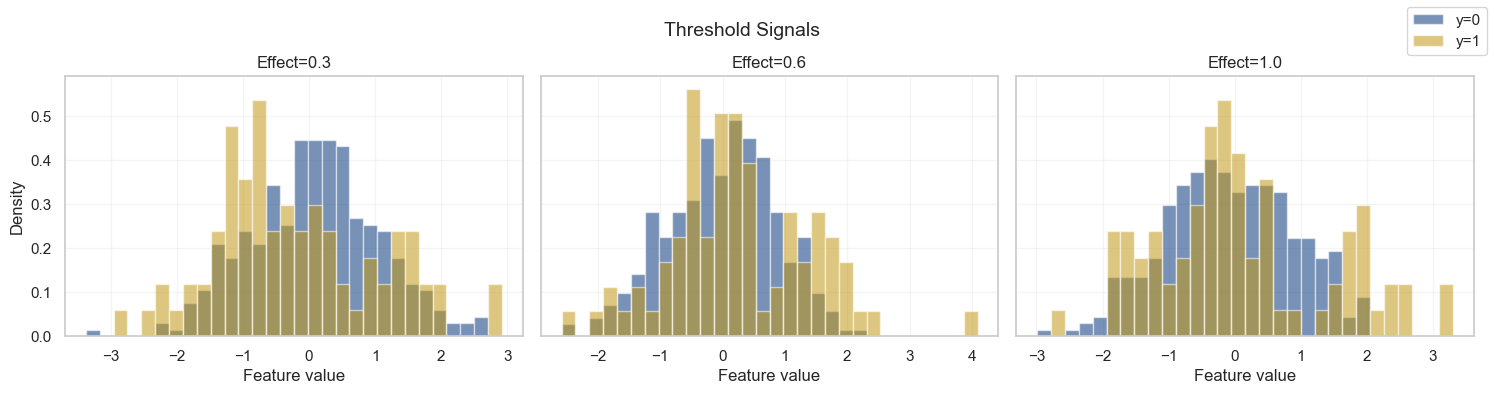

In [6]:
for signal_type in SIGNAL_TYPES:
    plot_signal_histograms(signal_type=signal_type, effects=effect_sizes)

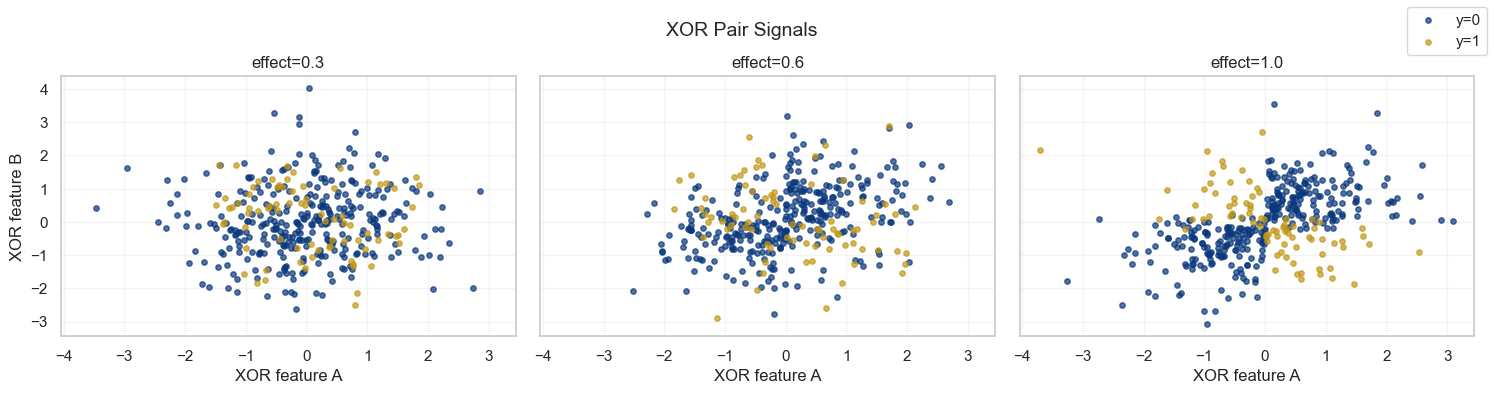

In [7]:
def plot_xor_scatter(effects: list[float]) -> None:
    fig, axes = plt.subplots(
        1,
        len(effects),
        figsize=(5 * len(effects), 4),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    selected_pairs = {
        effect: (pairs[0] if pairs else None)
        for effect, pairs in xor_records_by_effect.items()
    }

    all_x = []
    all_y = []
    for effect in effects:
        pair = selected_pairs.get(effect)
        if pair is None:
            continue
        idx_a, idx_b = pair
        all_x.append(X[:, idx_a])
        all_y.append(X[:, idx_b])

    if all_x and all_y:
        x_min = min(arr.min() for arr in all_x)
        x_max = max(arr.max() for arr in all_x)
        y_min = min(arr.min() for arr in all_y)
        y_max = max(arr.max() for arr in all_y)
        x_pad = 0.05 * (x_max - x_min + 1e-9)
        y_pad = 0.05 * (y_max - y_min + 1e-9)
    else:
        x_min, x_max = -3.0, 3.0
        y_min, y_max = -3.0, 3.0
        x_pad = 0.0
        y_pad = 0.0

    cls0 = y == 0
    cls1 = y == 1

    for ax, effect in zip(axes, effects):
        pair = selected_pairs.get(effect)

        if pair is None:
            ax.set_title(f"effect={effect} (no pairs)")
            ax.set_xlabel("XOR feature A")
            continue

        idx_a, idx_b = pair
        ax.scatter(X[cls0, idx_a], X[cls0, idx_b], s=15, alpha=0.7, color="#0A387D", label="y=0")
        ax.scatter(X[cls1, idx_a], X[cls1, idx_b], s=15, alpha=0.7, color="#C29717", label="y=1")

        ax.set_title(f"effect={effect}")
        ax.set_xlabel("XOR feature A")
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("XOR feature B")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")

    fig.suptitle("XOR Pair Signals", y=0.95, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_xor_scatter(effect_sizes)